In [3]:
import sys
import os




project_path = r"C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder"
if project_path not in sys.path:
    sys.path.append(project_path)

import track_builder as tb

import pandas as pd
import track_builder as tb

import os
from dotenv import load_dotenv

load_dotenv()

saving_path = os.getenv("SAVING")
track_output_path = os.path.join(saving_path, "tracks")
df_output_path = os.path.join(saving_path, "df")
os.makedirs(track_output_path, exist_ok=True)
os.makedirs(df_output_path, exist_ok=True)

BASE_PATH = r"C:\Users\lamin\Documents\maitrise\ASTD\data"
YEAR      = 2019

MONTHS_TO_LOAD = [1, 2, 3]

USECOLS   = "default"
SAMPLING  = [0, -1]

COLS_REQUIRED = [
    "shipid",
    "date_time_utc",
    "latitude",
    "longitude",
    "astd_cat",
    "flagname",
    "iceclass",
    "sizegroup_gt"
]


In [2]:

df_sampling = tb.load_astd_monthly(
    BASE_PATH, YEAR, months=MONTHS_TO_LOAD, progress=True,
    usecols=USECOLS, sampling=0.1, remove_nan_rows=COLS_REQUIRED
)





c:\Users\lamin\miniconda3\envs\astd-track\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading ASTD CSVs:   0%|          | 0/3 [00:07<?, ?it/s]

INFO: Failed to read with separator ';'. Pandas error: Error tokenizing data. C error: no error message set
INFO: Failed to read with separator ','. Pandas error: Usecols do not match columns, columns expected but not found: ['date_time_utc', 'sizegroup_gt', 'longitude', 'shipid', 'latitude', 'flagname', 'astd_cat', 'iceclass', 'sec_nextpoint', 'dist_nextpoint']


ValueError: Could not parse CSV C:\Users\lamin\Documents\maitrise\ASTD\data\ASTD_area_level3_201901.csv with any tried configuration.

In [12]:
df_sampling

,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude
0,2159,2019-01-01 00:00:28+00:00,Faeroe Islands,FS Ice Class 1C,Fishing vessels,< 1000 GT,0.825536,399,-6.727805,62.110680
1,2369,2019-01-01 00:00:32+00:00,Russia,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,4437.861328,674,14.337200,75.838104
2,11779,2019-01-01 00:00:47+00:00,Sweden,FS Ice Class 1C,Other activities,1000 - 4999 GT,2.619557,540,26.905170,60.424793
3,3157,2019-01-01 00:00:54+00:00,Russia,FS Ice Class 1A Super,General cargo ships,5000 - 9999 GT,2536.386719,370,31.768499,70.842163
4,2837,2019-01-01 00:00:59+00:00,Norway,FS Ice Class 1C,Passenger ships,10000 - 24999,2824.011963,362,11.392800,64.917236
...,...,...,...,...,...,...,...,...,...,...
1071112,2955,2019-03-31 23:58:57+00:00,Netherlands,FS Ice Class 1A,General cargo ships,1000 - 4999 GT,1735.134033,309,8.059359,64.142700
1071113,3095,2019-03-31 23:59:00+00:00,Finland,FS Ice Class 1A,General cargo ships,1000 - 4999 GT,4.240112,50,17.491224,62.506023
1071114,3044,2019-03-31 23:59:19+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,1650.611572,360,5.594358,62.594727
1071115,9225,2019-03-31 23:59:43+00:00,Germany,FS Ice Class 1A,General cargo ships,1000 - 4999 GT,2138.277344,360,-17.486055,66.375710


In [ ]:
# Appel propre de la fonction
fig = tb.plot_ship_tracks(
    df_sampling,
    show_points=True,
    color_lines=False,
    color_by=None,
    title="Raw AIS Data Density (Sampled)",
    

    point_opacity=0.05,        
    fixed_color="rgb(31, 119, 180)" 
)

fig.update_layout(
    showlegend=False
)


fig.show()

In [4]:
fig = tb.visualization.visualizer.plot_sampled_positions_unicolor_transparent(
    df_sampling,
    every_n=80,          # ajuste pour avoir un rendu “léger”
    bin_decimals=3,      # 3 -> ~100m ; 2 -> ~1km (plus d’empilement)
    alpha_max=0.35,
    alpha_min=0.02,
    decay=0.80,
    size=3,
    rgb=(0, 120, 255),
    map_style="open-street-map",
    title="ASTD points (sampled), starting point of the algorithm",
    hover=False,
)
fig.show()


In [37]:
periods = {
    2019: [7, 8, 9, 10, 11, 12],  # Jul, Aug, Sep, Oct, Nov, Dec
    2020: [1, 2, 3, 4, 5, 6]      # Jan, Feb, Mar, Apr, May, Jun
}

In [4]:
df_parquet_file = os.path.join(df_output_path, "first_and_last_of_12month_2019_2020_astd_data.parquet")

if os.path.exists(df_parquet_file):
    df_for_track = pd.read_parquet(df_parquet_file)
else:
    df_for_track = tb.load_astd_periods(
        BASE_PATH, periods, progress=True,
        usecols=USECOLS, sampling=SAMPLING, remove_nan_rows=COLS_REQUIRED
    )

    
    df_for_track.to_parquet(df_parquet_file, index=False)

df_for_track

,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude
0,6415,2019-07-01 00:00:00+00:00,Finland,FS Ice Class 1A Super,Ro-Ro cargo ships,5000 - 9999 GT,88.901512,12,19.696810,59.812855
1,5672,2019-07-01 00:00:00+00:00,Norway,FS Ice Class 1B,Passenger ships,25000 - 49999,1.673997,539,5.820747,62.338879
2,2271,2019-07-01 00:00:02+00:00,Norway (Nis),FS Ice Class 1C,General cargo ships,< 1000 GT,3.069902,479,-6.800155,62.235966
3,4217,2019-07-01 00:00:05+00:00,Liberia,FS Ice Class 1A,Ro-Ro cargo ships,5000 - 9999 GT,5.633149,749,18.396992,69.633362
4,3753,2019-07-01 00:00:05+00:00,Faeroe Islands,FS Ice Class 1C,Fishing vessels,< 1000 GT,2153.114014,379,-7.281625,61.839897
...,...,...,...,...,...,...,...,...,...,...
3036145,1046,2020-06-30 23:59:54+00:00,Finland,FS Ice Class 1A Super,Chemical tankers,5000 - 9999 GT,74.190002,11,19.137196,60.647449
3036146,1792,2020-06-30 23:59:57+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,1641.155029,289,-18.239319,63.413197
3036147,182,2020-06-30 23:59:57+00:00,Malta,FS Ice Class 1C,General cargo ships,5000 - 9999 GT,2473.079102,370,16.557249,68.613266
3036148,401,2020-06-30 23:59:57+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,2.590000,219,-22.418816,63.839622


In [5]:
df_parquet_file2 = os.path.join(df_output_path, "all_12month_2019_2020_astd_data2_without_nan_col.parquet")

if os.path.exists(df_parquet_file2):
    df = pd.read_parquet(df_parquet_file2)
else:
    df = tb.load_astd_periods(
        BASE_PATH, periods=periods, progress=True,
        usecols=USECOLS, sampling=None, remove_nan_rows=COLS_REQUIRED
    )
    
    df.to_parquet(df_parquet_file2, index=False)

df

,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude
0,5672,2019-07-01 00:00:00+00:00,Norway,FS Ice Class 1B,Passenger ships,25000 - 49999,1.673997,539,5.820747,62.338879
1,6415,2019-07-01 00:00:00+00:00,Finland,FS Ice Class 1A Super,Ro-Ro cargo ships,5000 - 9999 GT,88.901512,12,19.696810,59.812855
2,2271,2019-07-01 00:00:02+00:00,Norway (Nis),FS Ice Class 1C,General cargo ships,< 1000 GT,3.069902,479,-6.800155,62.235966
3,3753,2019-07-01 00:00:05+00:00,Faeroe Islands,FS Ice Class 1C,Fishing vessels,< 1000 GT,2153.114014,379,-7.281625,61.839897
4,4217,2019-07-01 00:00:05+00:00,Liberia,FS Ice Class 1A,Ro-Ro cargo ships,5000 - 9999 GT,5.633149,749,18.396992,69.633362
...,...,...,...,...,...,...,...,...,...,...
46387897,2392,2020-06-30 23:59:54+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,277.786011,162,-12.215353,64.421120
46387898,401,2020-06-30 23:59:57+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,2.590000,219,-22.418816,63.839622
46387899,1792,2020-06-30 23:59:57+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,1641.155029,289,-18.239319,63.413197
46387900,182,2020-06-30 23:59:57+00:00,Malta,FS Ice Class 1C,General cargo ships,5000 - 9999 GT,2473.079102,370,16.557249,68.613266


In [6]:
# verify if .parquet file exists, if yes load it, else build tracks and save it
parquet_file_path = os.path.join(track_output_path, "tracks_2019_for_12_month_2019_2020.parquet")

if os.path.exists(parquet_file_path):
    tracks = pd.read_parquet(parquet_file_path)
else:
    tracks = tb.build_ship_tracks(df_for_track,
                                  max_time_gap_hours=25,
                                  max_distance_km=400,
                                  min_track_length=1,
                                  matching_strategy="balanced",
                                  return_logs=False,
                                  )
    tracks.to_parquet(parquet_file_path)

tracks

,month,segment_id,track_id
0,2019-07,5672,1
1,2019-08,15,1
2,2019-07,6415,2
3,2019-07,2271,3
4,2019-08,2570,3
...,...,...,...
13348,2020-06,5364,5814
13349,2020-06,18092,5815
13350,2020-06,16254,5816
13351,2020-06,6240,5817


In [47]:
# tracks that span at least 3 months
month_counts = tracks.groupby("track_id")["month"].nunique()
multi_month_ids = month_counts[month_counts == 12].index

print("Number of tracks spanning at least 8 months for 12 months of data:", len(multi_month_ids))
tracks[tracks["track_id"].isin(multi_month_ids)].head(10)


Number of tracks spanning at least 8 months for 12 months of data: 125


,month,segment_id,track_id
3,2019-07,2271,3
4,2019-08,2570,3
5,2019-09,2575,3
6,2019-10,1863,3
7,2019-11,1806,3
8,2019-12,1627,3
9,2020-01,1556,3
10,2020-02,1646,3
11,2020-03,2201,3
12,2020-04,2009,3


computing typical speeds...


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:382: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:170: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Cleaning completed: 96499 'ghost' or aberrant points removed.


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\io\astd_loader.py:587: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



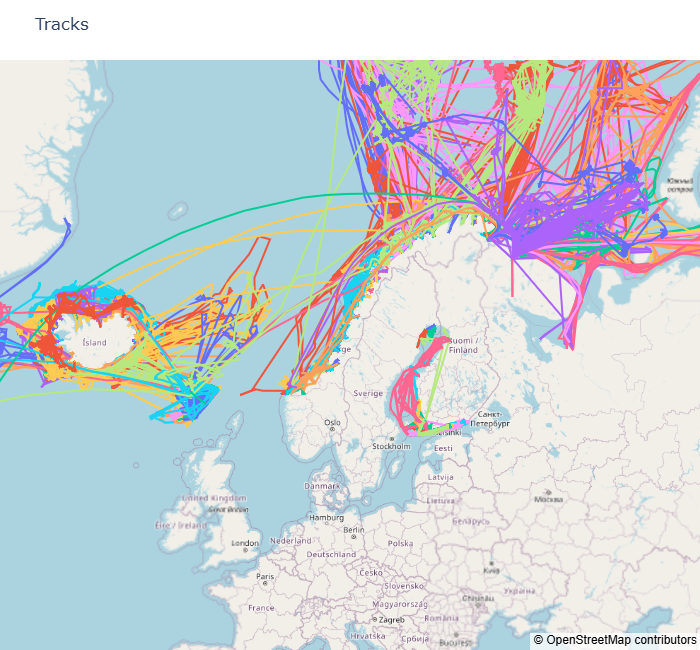

In [ ]:


work = tb.build_light_multi_track_data(track_table=tracks, track_sampling=125,
                                        positions_df=df, n_tracks_length=12, 
                                        preprocess_positions=True, )

fig = tb.plot_ship_tracks(
    work,
    color_by="track_id",
    color_mode="categorical",
    show_points=False,
    map_style="open-street-map",
    title="Tracks",
)
fig.update_layout(showlegend=False)
fig.show()

computing typical speeds...


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:382: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:170: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Cleaning completed: 39 'ghost' or aberrant points removed.


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\io\astd_loader.py:587: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



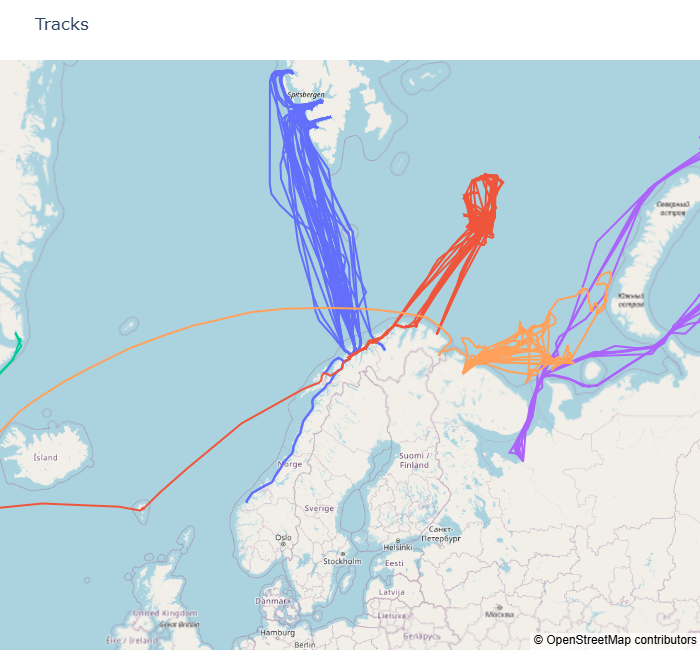

In [ ]:
work = tb.build_light_multi_track_data(track_table=tracks, specific_track_ids=[504, 520, 711, 599, 299],
                                        positions_df=df, n_tracks_length=12, 
                                        preprocess_positions=True, )

fig = tb.plot_ship_tracks(
    work,
    color_by="track_id",
    color_mode="categorical",
    show_points=False,
    map_style="open-street-map",
    title="Tracks",
)
fig.update_layout(showlegend=False)
fig.show()

computing typical speeds...


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:382: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:170: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Cleaning completed: 17864 'ghost' or aberrant points removed.


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\io\astd_loader.py:587: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



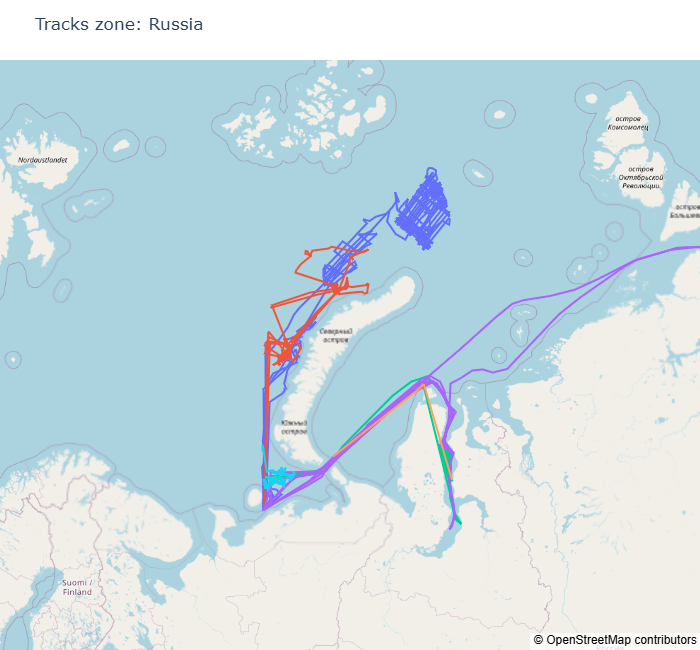

In [ ]:

work = tb.build_light_multi_track_data(track_table=tracks, track_sampling=50,
                                        positions_df=df, n_tracks_length=8, 
                                        preprocess_positions=True, region="russia")

fig = tb.plot_ship_tracks(
    work,
    color_by="track_id",
    color_mode="categorical",
    show_points=False,
    map_style="open-street-map",
    title="Tracks zone: Russia",
)
fig.update_layout(showlegend=False)
fig.show()

computing typical speeds...


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:382: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:170: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Cleaning completed: 17864 'ghost' or aberrant points removed.


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\io\astd_loader.py:587: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



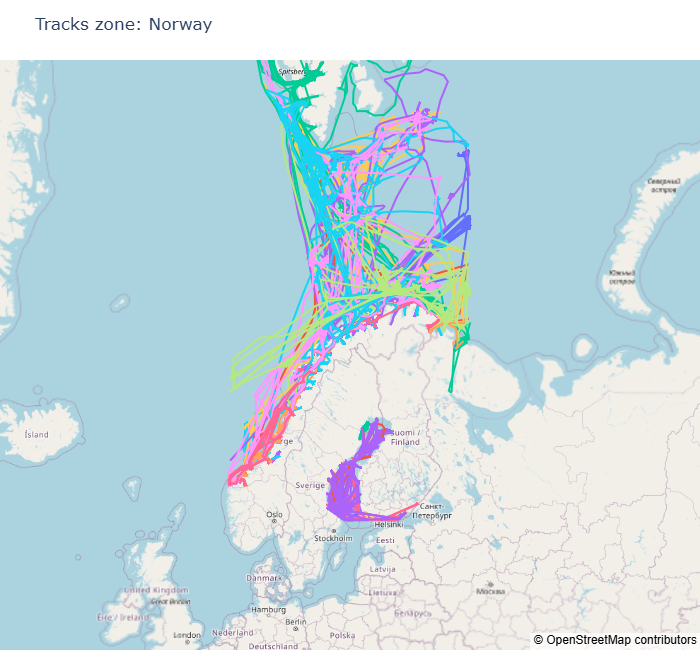

In [ ]:

work = tb.build_light_multi_track_data(track_table=tracks, track_sampling=50,
                                        positions_df=df, n_tracks_length=8, 
                                        preprocess_positions=True, region="norway")

fig = tb.plot_ship_tracks(
    work,
    color_by="track_id",
    color_mode="categorical",
    show_points=False,
    map_style="open-street-map",
    title="Tracks zone: Norway",
)
fig.update_layout(showlegend=False)
fig.show()

computing typical speeds...


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:382: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:170: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Cleaning completed: 26318 'ghost' or aberrant points removed.


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\io\astd_loader.py:587: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



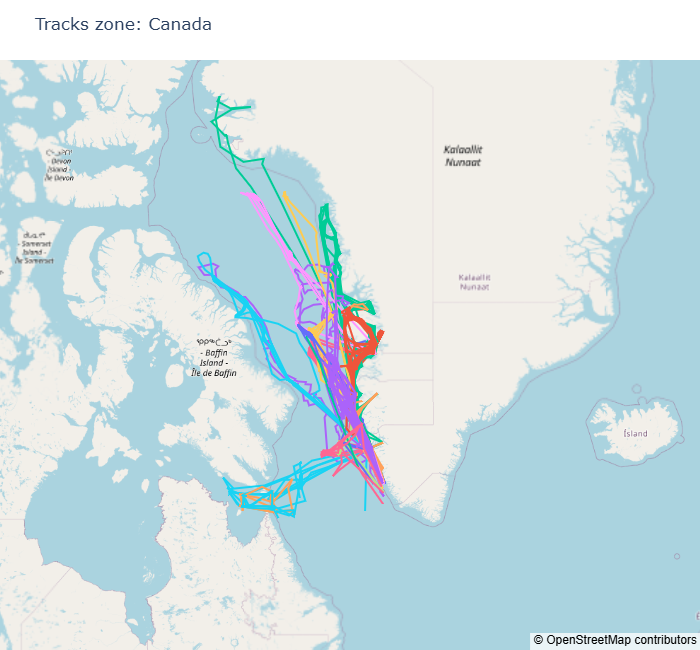

In [ ]:

work = tb.build_light_multi_track_data(track_table=tracks, track_sampling=200,
                                        positions_df=df, n_tracks_length=6, 
                                        preprocess_positions=True, region="canada")

fig = tb.plot_ship_tracks(
    work,
    color_by="track_id",
    color_mode="categorical",
    show_points=False,
    map_style="open-street-map",
    title="Tracks zone: Canada",
)
fig.update_layout(showlegend=False)
fig.show()

In [51]:
track_504 = tb.load_track_data(track_ids=[504], track_table=tracks, base_path=BASE_PATH, chunksize=500_000)

Batch loading 1 tracks: 100%|██████████| 12/12 [06:01<00:00, 30.09s/it]


computing typical speeds...
Cleaning completed: 3 'ghost' or aberrant points removed.


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:170: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

